Տնային առաջադրանքը կատարելու վերջնաժամկետը **12.07.2021 15:30** է։ Առաջադրանքները կատարելուց հետո, պետք է 

1. ներբեռնեք այս ֆայլը ձեր համակարգիչ (`File` $\to$ `Download .ipynb`)

2. ներբեռնեք լրացված ``.py`` ֆայլերը

3. վերոնշյալ ֆայլերը ``.zip`` արեք և վերնագրեք հետևյալ ֆորմատով՝ 
    *HW8_AnunAzganun.zip* 

4. ուղարկեք ֆայլը **fast.1991.ml@gmail.com** հասցեին` նամակի թեմա (subject) դաշտում գրելով **ML8**

**Ուշադրություն**․ 
Վերոնշյալ պայմաններին չբավարարելու դեպքում ձեր աշխատանքը չի գնահատվի։

**Ուշադրություն**․ 
Տնայինի մաս է կազմում նաև "Viola Jones" ալգորիթմի իմպլեմենտացիայի լրացումը: \\
Տես՝ `Labs/Viola Jones/` 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn.datasets

plt.style.use('seaborn-whitegrid') # Plot style

%load_ext autoreload
%autoreload 2

from unsupervised import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
centroids = np.random.choice(np.arange(data.shape[0]), size = 2)
np.array(data.iloc[centroids[0]])

array(['P6', 1, 6], dtype=object)

In [19]:
a = np.argmin(np.array(data[['x','y']]), axis = 1)

In [21]:
a

array([0, 0, 1, 0, 0, 0, 0, 1, 0], dtype=int64)

In [24]:
np.array(data[['x','y']])[a]

array([[0, 1],
       [0, 1],
       [1, 1],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1],
       [1, 1],
       [0, 1]], dtype=int64)

In [17]:
data[['x','y']]

,x,y
0,0,1
1,1,1
2,4,0
3,2,3
4,0,5
5,1,6
6,3,6
7,7,4
8,6,8


# Clustering

## K-Means

Explore the visualization of the K-means algorithm at [this website](https://www.naftaliharris.com/blog/visualizing-k-means-clustering). 

Note that you must click on the buttons `Update Centroids` and `Reassign Points` multiple times, until convergence (until there are no changes in the contents of clusters). 

For example, at this website run K-means on the `Uniform dataset` initializing with `K=4` randomly chosen cluster centers.

### Task 1

Try to cluster the `Smiley Face` dataset on the same website by choosing initial cluster centers manually. 

Is it possible to choose the centers such that there would be `one cluster` which only contains the `left eye` of the smiley?

### Task 2

Complete the `KMeans` algorithm in `Labs/Lab8/unsupervised.py` script and use it to find `2, 3` and `4` clusters on this toy data. 

In [3]:
data = pd.DataFrame(
    {'ID':['P1','P2','P3','P4','P5','P6','P7','P8','P9'],
    'x':[0,1,4,2,0,1,3,7,6],
    'y':[1,1,0,3,5,6,6,4,8]})
data

,ID,x,y
0,P1,0,1
1,P2,1,1
2,P3,4,0
3,P4,2,3
4,P5,0,5
5,P6,1,6
6,P7,3,6
7,P8,7,4
8,P9,6,8


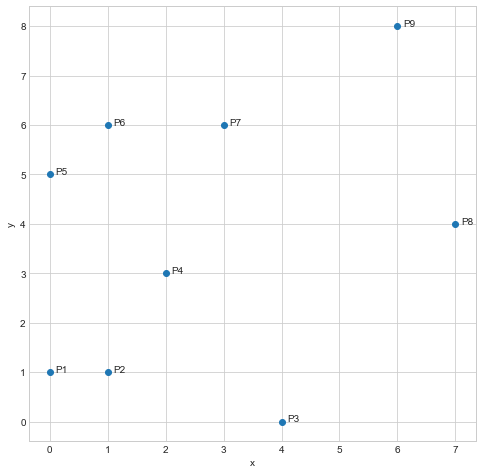

In [4]:
plt.rcParams['figure.figsize'] = [8, 8]
plt.scatter(data['x'], data['y'])
plt.xlabel('x')
plt.ylabel('y')

# adding text next to the points  
for i, label in enumerate(data['ID']):
    x = data['x'][i]+0.1
    y = data['y'][i]
    plt.annotate(label,(x,y))

In [6]:
def plot_data(X, model):
  """
  Helper function to plot the data points
  in the toy dataset and also plots the centroids
  using the fitted model 
  """
  plt.figure(figsize=(8, 6))
  for i in range(model.k):
    plt.scatter(data.loc[model.labels == i, 'x'],
             data.loc[model.labels == i, 'y'],
             marker='o' , label=f'{i}')
    plt.plot(model.centroids[i][0],
             model.centroids[i][1],
             marker='*', markersize=12) 
    
  # adding text next to the points  
  for i, label in enumerate(data['ID']):
    x = data['x'][i]+0.1
    y = data['y'][i]
    plt.annotate(label,(x,y))

  plt.legend()
  plt.show()

For each number of clusters ($K$) run the algorithm several times and plot the results, to see how whether the clusters differ during each run.

In [ ]:
model = KMeans(k=2, tol=0.001)
model.fit(data[['x', 'y']])
plot_data(data, model)

In [ ]:
model = KMeans(k=3, tol=0.001)
model.fit(data[['x', 'y']])
plot_data(data, model)

In [ ]:
model = KMeans(k=4, tol=0.001)
model.fit(data[['x', 'y']])
plot_data(data, model)

You can also implement `K-medoids` algorithm similar to `K-means` with some modifications.

## Hierarchichal Clustering

### Task 1
Perform a hierarchical clustering of the toy dataset introduced above. Calculate distances between instances using Euclidean distance in the 2-dimensional space determined by features `x` and `y`. For calculating distances between clusters use `single linkage` method. Each time when you merge two clusters (even if they consist of only a single instance) report the following

* List of instance IDs in one cluster
* List of instance IDs in the other cluster
* Distance between these clusters 

Sometimes there can be alternatives with the same distances, in such case just decide randomly which of the alternatives to choose. Do this steps manually (without programming).

For example, the first three clusters will be 

$$[P1] + [P2] \ \rightarrow \   d=\sqrt{(0-1)^2+(1-1)^2}=\sqrt{1}=1$$
$$[P5] + [P6] \ \rightarrow \   d=\sqrt{(0-1)^2+(5-6)^2}=\sqrt{2} \approx 1.41$$
$$[P5,P6] + [P7] \ \rightarrow \   d=\sqrt{(1-3)^2+(6-6)^2}=\sqrt{4} = 2$$

Continue forming the clusters.



### Task 2
After finishing the above, do the same with `complete linkage` method and report the results similarly.

In this case the first three clusters will be

$$[P1] + [P2] \ \rightarrow \   d=\sqrt{(0-1)^2+(1-1)^2}=\sqrt{1}=1$$
$$[P5] + [P6] \ \rightarrow \   d=\sqrt{(0-1)^2+(5-6)^2}=\sqrt{2} \approx 1.41$$
$$[P2,P1] + [P4] \ \rightarrow \   d=\sqrt{(0-2)^2+(1-3)^2}=\sqrt{8} \approx 2.83$$

Continue forming the clusters.

### Task 3

Now we will draw the dendrograms of both clusterings. 
You should 

* find a subcluster in the single linkage dendrogram such that none of the subclusters in the complete linkage dendrogram consists of exactly the same set of instances. 

* find a subcluster in the complete linkage dendrogram such that none of the subclusters in the single linkage dendrogram consists of exactly the same set of instances. 

The code for drawing a dendrogram of the clustering from the Task 1 and 2 are written below. You should also check your answers in those tasks with the resulting dendrograms.


In [ ]:
from scipy.cluster import hierarchy
plt.rcParams['figure.figsize'] = [15, 8]

single = hierarchy.linkage(data[['x','y']], 'single')
plt.subplot(1,2,1)
plt.title('Single linkage')
single_dm = hierarchy.dendrogram(single, labels=data.ID.tolist(), color_threshold=0)

complete = hierarchy.linkage(data[['x','y']], 'complete')
plt.subplot(1,2,2)
plt.title('Complete linkage')
complete_dm = hierarchy.dendrogram(complete, labels=data.ID.tolist(), color_threshold=0)

plt.show()

Now complete the `HierarchicalClustering` algorithm in `Labs/Lab8/unsupervised.py` script and compare the results with your calculations above. 

In [ ]:
# YOUR CODE HERE

# DBSCAN

Implement the `DBSCAN` algorithm in `Labs/Lab8/unsupervised.py` script and run it on the same toy example with different hyperparameters. 

In [ ]:
# YOUR CODE HERE

# Dimensionality Reduction

#PCA

Implement the `PCA` class in `Lab_files/Lab8/unsupervised.py` file. We will use the `Iris` dataset for testing the implementation.

In [ ]:
iris = sklearn.datasets.load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris.head()

In [ ]:
model = PCA(nr_components=2)
X_reduced = model.fit_transform(df_iris)

You should get about $97.77\%$ explained variance with $2$ principal components.

In [ ]:
model.explained_variance_ratio

In [ ]:
colors = np.array(['red', 'blue', 'green'])

plt.scatter(X_reduced.iloc[:,0], X_reduced.iloc[:,1],
            color=colors[iris.target]);

#t-SNE

Implement the `TSNE` class in `Lab_files/Lab8/unsupervised.py` file and test it on Iris dataset as we did with PCA.

In [ ]:
# YOUR CODE HERE